In [19]:
!pip install --upgrade torch torchvision

# Phase 3

Train/Val/Test Split

In [20]:
# Train/Val/Test Split

from sklearn.model_selection import train_test_split
import json
import os

# Load data bersih dari Fase 2
with open("./data/cleaned_articles.json", "r", encoding="utf-8") as f:
    cleaned_data = json.load(f)

labels = [d["label"] for d in cleaned_data]

# Split 1: 80% train, 20% temp
train_data, temp_data = train_test_split(
    cleaned_data,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# Split 2: 50/50 dari temp → 10% val, 10% test
temp_labels = [d["label"] for d in temp_data]
val_data, test_data = train_test_split(
    temp_data,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"Train : {len(train_data)} artikel")
print(f"Val   : {len(val_data)} artikel")
print(f"Test  : {len(test_data)} artikel")

# Simpan
data_dir = "./data"
os.makedirs(data_dir, exist_ok=True)

for name, data in [("train", train_data), ("val", val_data), ("test", test_data)]:
    path = os.path.join(data_dir, f"dataset_{name}.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    print(f"  ✅ Saved {path}")

Train : 8116 artikel
Val   : 1014 artikel
Test  : 1015 artikel
  ✅ Saved ./data/dataset_train.json
  ✅ Saved ./data/dataset_val.json
  ✅ Saved ./data/dataset_test.json


Tokenisasi

In [21]:
from transformers import AutoTokenizer, DataCollatorWithPadding
from datasets import Dataset
import json

MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 512

# 1. Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 2. Load data dari file JSON
def load_dataset_from_json(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)
    return Dataset.from_list([
        {"text": d["text"], "label": d["label"]}
        for d in data
    ])

train_ds = load_dataset_from_json("./data/dataset_train.json")
val_ds   = load_dataset_from_json("./data/dataset_val.json")
test_ds  = load_dataset_from_json("./data/dataset_test.json")

# 3. Fungsi tokenisasi
def tokenize_fn(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

# 4. Tokenisasi semua dataset
train_ds = train_ds.map(tokenize_fn, batched=True, desc="Tokenisasi train")
val_ds   = val_ds.map(tokenize_fn, batched=True, desc="Tokenisasi val")
test_ds  = test_ds.map(tokenize_fn, batched=True, desc="Tokenisasi test")

# 5. Set format untuk PyTorch
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Tokenisasi train:   0%|          | 0/8116 [00:00<?, ? examples/s]

Tokenisasi val:   0%|          | 0/1014 [00:00<?, ? examples/s]

Tokenisasi test:   0%|          | 0/1015 [00:00<?, ? examples/s]

# Phase 4
Training model dengan data yang telah ditokenisasikan

Konfigurasi

In [22]:
# KONFIGURASI
import numpy as np
from sklearn.metrics import classification_report, accuracy_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset
import json

MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 512
NUM_LABELS = 5
LABEL_NAMES = ["politik", "ekonomi", "teknologi", "olahraga", "hiburan"]
OUTPUT_DIR = "./output/indobert-berita-classifier"

Load model

In [23]:
# Load model

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={i: name for i, name in enumerate(LABEL_NAMES)},
    label2id={name: i for i, name in enumerate(LABEL_NAMES)},
)

print(f"Model loaded: {MODEL_NAME}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: indobenchmark/indobert-base-p1
Total parameters: 124,445,189


Fungsi evaluasi metrik

In [24]:
# Evaluasi Metrik

def compute_metrics(eval_pred):
    """Hitung metrik evaluasi pada setiap akhir epoch."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    acc = accuracy_score(labels, predictions)
    report = classification_report(
        labels, predictions,
        target_names=LABEL_NAMES,
        output_dict=True,
        zero_division=0,
    )
    
    return {
        "accuracy": acc,
        "macro_f1": report["macro avg"]["f1-score"],
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "weighted_f1": report["weighted avg"]["f1-score"],
    }

Training arguments

In [25]:
# Training arguments

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    
    # Hyperparameters
    num_train_epochs=4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    
    # Evaluation & Saving
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    
    # Logging
    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=50,
    report_to="none",
    
    # Reproducibility
    seed=42,
    
    # GPU Optimization (uncomment jika GPU mendukung)
    # fp16=True,
    # gradient_accumulation_steps=2,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer

In [26]:
# Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    data_collator=data_collator, 
)

Training model

In [27]:
# Training

print("\n" + "="*60)
print("MULAI TRAINING")
print("="*60)
print(f"  Model          : {MODEL_NAME}")
print(f"  Train samples  : {len(train_ds)}")
print(f"  Val samples    : {len(val_ds)}")
print(f"  Epochs         : {training_args.num_train_epochs}")
print(f"  Batch size     : {training_args.per_device_train_batch_size}")
print(f"  Learning rate  : {training_args.learning_rate}")
print(f"  Total steps    : {len(train_ds) // training_args.per_device_train_batch_size * int(training_args.num_train_epochs)}")
print("="*60 + "\n")

train_result = trainer.train()

# Log training result
print(f"\n  Training time     : {train_result.metrics['train_runtime']:.0f} detik")
print(f"  Samples/detik     : {train_result.metrics['train_samples_per_second']:.1f}")


MULAI TRAINING
  Model          : indobenchmark/indobert-base-p1
  Train samples  : 8116
  Val samples    : 1014
  Epochs         : 4
  Batch size     : 8
  Learning rate  : 2e-05
  Total steps    : 4056



Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1
1,0.168922,0.196789,0.956607,0.956682,0.957387,0.956621,0.956674
2,0.081090,0.181102,0.965483,0.965445,0.965988,0.965488,0.965443
3,0.050318,0.210282,0.964497,0.964582,0.965119,0.964488,0.964581
4,0.002653,0.188154,0.970414,0.970437,0.970836,0.970419,0.970435


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Training time     : 4026 detik
  Samples/detik     : 8.1


# Phase 5

Evaluasi Model

In [28]:
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)
import matplotlib.pyplot as plt
import json
import os

Prediksi di test set

In [29]:
print("Menjalankan prediksi di test set...")
predictions = trainer.predict(test_ds)

preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

Menjalankan prediksi di test set...


Classification report

In [30]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT — TEST SET")
print("="*60)

report_text = classification_report(labels, preds, target_names=LABEL_NAMES)
print(report_text)

report_dict = classification_report(labels, preds, target_names=LABEL_NAMES, output_dict=True)

# Simpan report sebagai JSON
report_path = os.path.join(OUTPUT_DIR, "classification_report.json")
with open(report_path, "w") as f:
    json.dump(report_dict, f, indent=2)
print(f"  ✅ Report disimpan ke: {report_path}")


CLASSIFICATION REPORT — TEST SET
              precision    recall  f1-score   support

     politik       0.96      0.95      0.95       203
     ekonomi       0.97      0.96      0.97       203
   teknologi       0.97      0.98      0.97       203
    olahraga       0.99      0.99      0.99       203
     hiburan       0.98      0.99      0.99       203

    accuracy                           0.97      1015
   macro avg       0.97      0.97      0.97      1015
weighted avg       0.97      0.97      0.97      1015

  ✅ Report disimpan ke: ./output/indobert-berita-classifier/classification_report.json


Confusion matrix

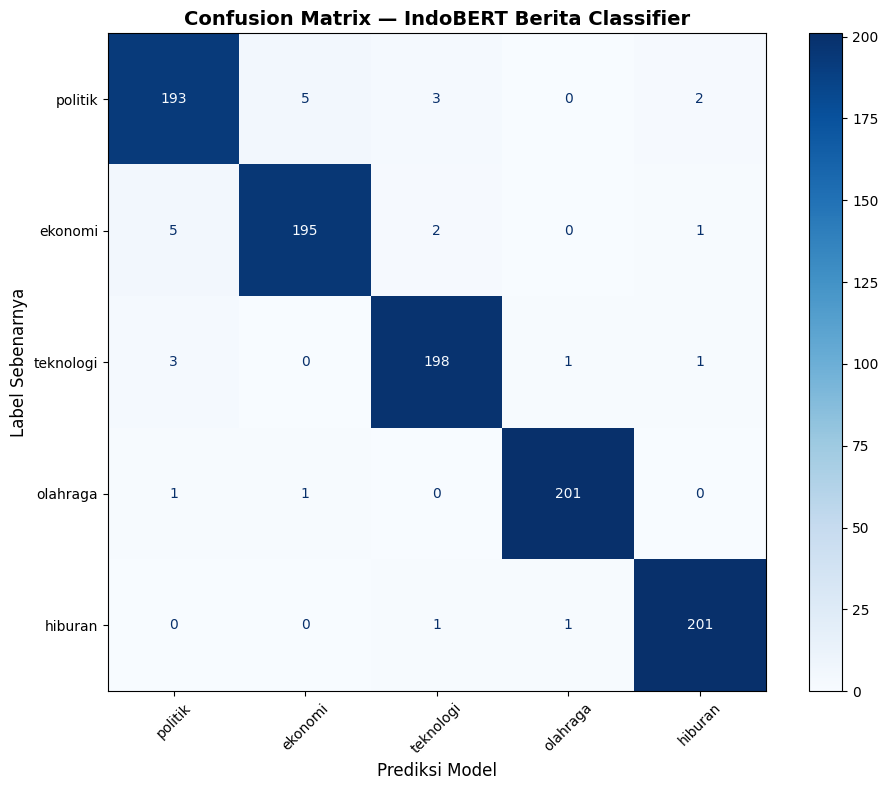

  ✅ Confusion matrix disimpan ke: ./output/indobert-berita-classifier/confusion_matrix.png


In [31]:
cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45,
)
ax.set_title("Confusion Matrix — IndoBERT Berita Classifier", fontsize=14, fontweight="bold")
ax.set_ylabel("Label Sebenarnya", fontsize=12)
ax.set_xlabel("Prediksi Model", fontsize=12)
plt.tight_layout()

cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  ✅ Confusion matrix disimpan ke: {cm_path}")

Ringkasan Evaluasi

In [32]:
print("\n" + "="*60)
print("RINGKASAN EVALUASI")
print("="*60)
print(f"  Accuracy       : {report_dict['accuracy']:.4f}")
print(f"  Macro F1       : {report_dict['macro avg']['f1-score']:.4f}")
print(f"  Weighted F1    : {report_dict['weighted avg']['f1-score']:.4f}")
print()
print("  Per kategori (F1-Score):")
for label in LABEL_NAMES:
    f1 = report_dict[label]["f1-score"]
    bar = "█" * int(f1 * 40)
    print(f"    {label:>12}: {f1:.3f} {bar}")


RINGKASAN EVALUASI
  Accuracy       : 0.9734
  Macro F1       : 0.9734
  Weighted F1    : 0.9734

  Per kategori (F1-Score):
         politik: 0.953 ██████████████████████████████████████
         ekonomi: 0.965 ██████████████████████████████████████
       teknologi: 0.973 ██████████████████████████████████████
        olahraga: 0.990 ███████████████████████████████████████
         hiburan: 0.985 ███████████████████████████████████████


# Phase 6

Export Model & Deployment

Simpan model

In [33]:
SAVE_DIR = "./output/saved_model"

# Simpan model + tokenizer
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"✅ Model disimpan ke: {SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model disimpan ke: ./output/saved_model


Verifikasi Model yang Disimpan

In [35]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=SAVE_DIR,
    tokenizer=SAVE_DIR,
    top_k=5,
    device="cpu",
)

# Test prediksi
sample_texts = [
    "Presiden Prabowo meresmikan proyek infrastruktur strategis nasional di Papua",
    "IHSG ditutup menguat 1,5 persen pada perdagangan Senin",
    "Apple meluncurkan iPhone 18 dengan chip A20 Bionic terbaru",
    "Timnas Indonesia lolos ke babak semifinal Piala AFF 2026",
    "Film Dilan 3 meraih penonton terbanyak sepanjang 2026",
]

print("VERIFIKASI MODEL TERSIMPAN")
print("="*60)
for text in sample_texts:
    result = classifier(text)
    top = result[0][0]
    print(f"\n  Teks: \"{text[:70]}...\"")
    print(f"  → Prediksi: {top['label']} ({top['score']:.2%})")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

VERIFIKASI MODEL TERSIMPAN

  Teks: "Presiden Prabowo meresmikan proyek infrastruktur strategis nasional di..."
  → Prediksi: politik (99.24%)

  Teks: "IHSG ditutup menguat 1,5 persen pada perdagangan Senin..."
  → Prediksi: ekonomi (99.97%)

  Teks: "Apple meluncurkan iPhone 18 dengan chip A20 Bionic terbaru..."
  → Prediksi: teknologi (99.96%)

  Teks: "Timnas Indonesia lolos ke babak semifinal Piala AFF 2026..."
  → Prediksi: olahraga (99.99%)

  Teks: "Film Dilan 3 meraih penonton terbanyak sepanjang 2026..."
  → Prediksi: hiburan (99.97%)
